In [1]:
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [38]:
df = pd.read_csv(r"d:\Churn prediction\data\churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
df.drop('customerID', axis=1, inplace=True)

In [30]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [40]:
df.drop('gender', axis=1, inplace=True)

In [41]:
#change total charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [42]:
df.isnull().sum()

SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [43]:
# handle missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\unick\AppData\Local\Temp\ipykernel_26056\959162640.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [35]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Female':1, 'Male':0})

In [44]:
def Feature_Engineering(df) :
    binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
    for col in binary_cols:
        df[col] = df[col].map({'Yes':1, 'No':0, 'Female':1, 'Male':0})

In [45]:
Feature_Engineering(df)

In [53]:
def Feature_Engineering(df) :
    service_cols = [
        'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
    ]
    #number of services each costomer used
    df['NumServices'] = df[service_cols].replace({'Yes':1, 'No':0}).sum(axis=1)

    # Avg monthly charge
    df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

    return df

In [31]:
df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

In [54]:
cat_cols = ['Contract','PaymentMethod','InternetService']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [55]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,NumServices,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,No phone service,No,Yes,No,No,...,29.85,0,2,False,False,False,True,False,False,False
1,0,0,0,34,1,No,Yes,No,Yes,No,...,1889.50,0,1,True,False,False,False,True,False,False
2,0,0,0,2,1,No,Yes,Yes,No,No,...,108.15,1,3,False,False,False,False,True,False,False
3,0,0,0,45,0,No phone service,Yes,No,Yes,Yes,...,1840.75,0,0,True,False,False,False,False,False,False
4,0,0,0,2,1,No,No,No,No,No,...,151.65,1,3,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,Yes,Yes,No,Yes,Yes,...,1990.50,0,4,True,False,False,False,True,False,False
7039,0,1,1,72,1,Yes,No,Yes,Yes,No,...,7362.90,0,4,True,False,True,False,False,True,False
7040,0,1,1,11,0,No phone service,Yes,No,No,No,...,346.45,0,3,False,False,False,True,False,False,False
7041,1,1,0,4,1,Yes,No,No,No,No,...,306.60,1,4,False,False,False,False,True,True,False


In [40]:
df = pd.get_dummies(df, drop_first=True , dtype=int)
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,True,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,False,...,False,True,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,False,...,True,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,False,True,True,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,84.80,1990.50,0,True,...,False,True,True,True,True,True,False,False,False,True
7039,0,1,1,72,1,1,103.20,7362.90,0,True,...,True,True,False,True,True,True,False,True,False,False
7040,0,1,1,11,0,1,29.60,346.45,0,False,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,0,4,1,1,74.40,306.60,1,True,...,False,False,False,False,False,False,False,False,False,True


In [41]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split

# X = all features except Churn
X = df.drop('Churn', axis=1)
y = df['Churn']  # already 0/1

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)

TotalCharges                             0.211154
MonthlyCharges                           0.184360
tenure                                   0.175843
InternetService_Fiber optic              0.044231
PaymentMethod_Electronic check           0.036330
Contract_Two year                        0.032693
PaperlessBilling                         0.028273
Partner                                  0.024646
OnlineSecurity_Yes                       0.023340
Contract_One year                        0.022502
TechSupport_Yes                          0.022303
OnlineBackup_Yes                         0.021778
SeniorCitizen                            0.021013
MultipleLines_Yes                        0.020677
Dependents                               0.020343
InternetService_No                       0.019539
DeviceProtection_Yes                     0.019318
StreamingMovies_Yes                      0.018417
StreamingTV_Yes                          0.018078
PaymentMethod_Mailed check               0.014138


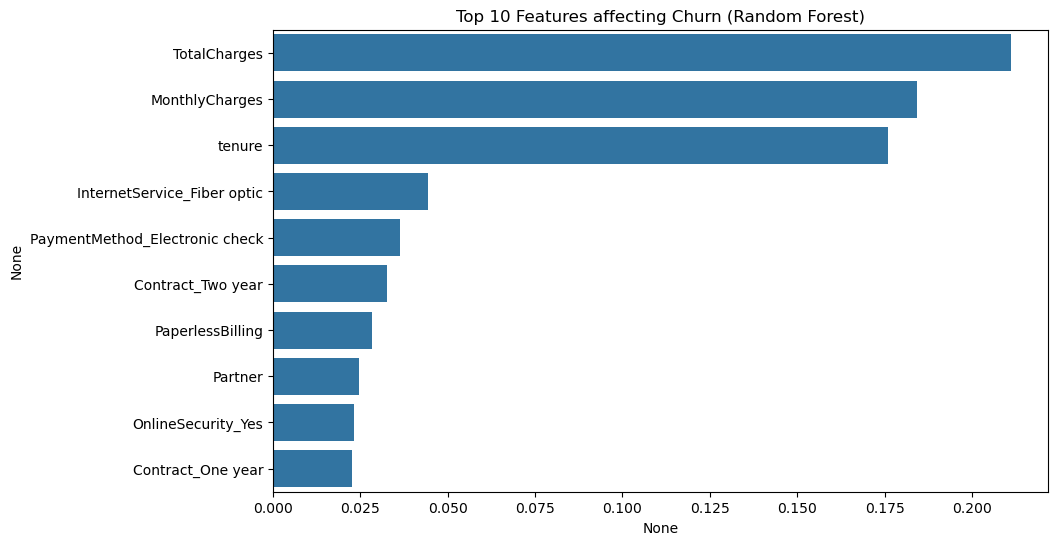

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(10).index
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance[top_features], y=top_features)
plt.title("Top 10 Features affecting Churn (Random Forest)")
plt.show()

In [47]:
# Suppose df has all features ready and target
df.to_csv('churn_features.csv', index=False)

In [48]:
df['NumServices'] = df[binary_cols].replace({'Yes':1, 'No':0}).sum(axis=1)

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1
...,...,...,...,...,...
7038,1,1,1,1,0
7039,1,1,1,1,0
7040,1,1,0,1,0
7041,1,0,1,1,1
